# GNN Feature Engineering for Hybrid Models

**Chapter 23: Knowledge Graphs for Financial AI**

**Docker image**: `ml4t-gpu`

This notebook tests whether graph-derived embeddings add information to a
tabular cross-sectional model. It trains a graph-attention autoencoder on a
pre-target correlation network, then compares tabular and hybrid ridge models
on the same held-out stocks.

**Learning objectives**

- Build a correlation network without using the target window.
- Train graph embeddings rather than treating random projections as learned features.
- Keep universe selection, scaling, and labels on the correct side of the evaluation boundary.
- Use paired fold results to distinguish an ablation result from a general claim about GNNs.

**Prerequisites**

- Familiarity with correlation matrices, ridge regression, and cross-sectional validation.
- The frozen NASDAQ Data Link Wiki Prices dataset available through `ML4T_DATA_PATH`.
- The `ml4t-gpu` Docker service on a CUDA-capable GPU for the production execution.

**Book reference**: Chapter 23, Section 23.5

In [1]:
"""Train graph embeddings and test their incremental cross-sectional value."""

from __future__ import annotations

from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch
from scipy import stats
from sklearn.model_selection import KFold
from torch import nn

from data import load_us_equities
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, show_with_alt

In [2]:
N_ASSETS = 200
LOOKBACK_DAYS = 504
TARGET_HORIZON = 21
CORRELATION_THRESHOLD = 0.5
EMBEDDING_DIM = 4
GNN_EPOCHS = 250
SEED = 42

In [3]:
set_global_seeds(SEED)
if not torch.cuda.is_available():
    raise RuntimeError("This production notebook requires a CUDA-capable GPU")
DEVICE = torch.device("cuda")

print("Configuration:")
print(f"  Assets: {N_ASSETS}")
print(f"  Correlation lookback: {LOOKBACK_DAYS} trading days")
print(f"  Target horizon: {TARGET_HORIZON} trading days")
print(f"  Correlation threshold: {CORRELATION_THRESHOLD}")
print(f"  Graph encoder device: {DEVICE}")

Configuration:
  Assets: 200
  Correlation lookback: 504 trading days
  Target horizon: 21 trading days
  Correlation threshold: 0.5
  Graph encoder device: cuda


## 1. Define the information boundary

The final 21 trading dates form one forward-return window. Liquidity ranking,
factor construction, and the correlation graph use only observations available
on or before `feature_as_of`. The evaluation cohort then retains ranked stocks
observed at both target endpoints. This complete-case filter supports one
held-out-stock comparison; it is not a point-in-time investable-universe rule
or a temporal backtest.

In [4]:
prices = load_us_equities(start_date="2015-01-01")
if prices.schema["timestamp"] == pl.Datetime:
    prices = prices.with_columns(pl.col("timestamp").dt.date())

prices = prices.with_columns((pl.col("adj_close") * pl.col("adj_volume")).alias("dollar_volume"))
trading_dates = prices["timestamp"].unique().sort().to_list()

required_dates = LOOKBACK_DAYS + TARGET_HORIZON + 1
if len(trading_dates) < required_dates:
    raise ValueError(f"Need at least {required_dates} trading dates, found {len(trading_dates)}")

feature_as_of = trading_dates[-TARGET_HORIZON - 1]
evaluation_end = trading_dates[-1]
universe_start = trading_dates[-TARGET_HORIZON - LOOKBACK_DAYS - 1]

print(f"Loaded {prices.height:,} rows for {prices['symbol'].n_unique():,} symbols")
print(f"Feature as-of date: {feature_as_of}")
print(f"Target window: {trading_dates[-TARGET_HORIZON]} to {evaluation_end}")

Loaded 2,224,952 rows for 3,097 symbols
Feature as-of date: 2018-02-26
Target window: 2018-02-27 to 2018-03-27


In [5]:
universe_history = prices.filter(
    pl.col("timestamp").is_between(universe_start, feature_as_of, closed="both")
)
liquidity_ranking = (
    universe_history.group_by("symbol")
    .agg(
        pl.col("dollar_volume").mean().alias("average_dollar_volume"),
        pl.col("adj_close").count().alias("observations"),
        pl.col("timestamp").max().alias("last_observation"),
    )
    .filter(
        (pl.col("observations") >= LOOKBACK_DAYS) & (pl.col("last_observation") == feature_as_of)
    )
    .sort("average_dollar_volume", descending=True)
)

Endpoint completeness defines the retrospective evaluation cohort. Sorting
again after the join preserves the pre-target liquidity ranking because joins
do not guarantee input order.

In [6]:
endpoint_complete_symbols = (
    prices.filter(pl.col("timestamp").is_in([feature_as_of, evaluation_end]))
    .group_by("symbol")
    .agg(pl.col("timestamp").n_unique().alias("endpoint_count"))
    .filter(pl.col("endpoint_count") == 2)
    .select("symbol")
)
universe = (
    liquidity_ranking.join(endpoint_complete_symbols, on="symbol", how="inner")
    .sort("average_dollar_volume", descending=True)
    .head(N_ASSETS)
)

selected_symbols = universe["symbol"].to_list()
if len(selected_symbols) != N_ASSETS:
    raise ValueError(
        f"Requested {N_ASSETS} endpoint-complete eligible symbols, found {len(selected_symbols)}"
    )

selected_prices = prices.filter(pl.col("symbol").is_in(selected_symbols))
print(
    f"Selected {len(selected_symbols)} endpoint-complete symbols "
    f"ranked using data through {feature_as_of}"
)
print(f"Leading symbols by pre-target liquidity: {selected_symbols[:10]}")

Selected 200 endpoint-complete symbols ranked using data through 2018-02-26
Leading symbols by pre-target liquidity: ['FB', 'NVDA', 'BAC', 'MSFT', 'TSLA', 'GOOGL', 'GOOG', 'NFLX', 'JPM', 'GE']


## 2. Build the pre-target correlation graph

Adjacency uses absolute correlation, so strong negative and positive
co-movement both create an edge. The graph itself is an input available at the
feature date. It does not use any return from the target window.

In [7]:
returns = (
    selected_prices.filter(pl.col("timestamp") <= feature_as_of)
    .sort(["symbol", "timestamp"])
    .with_columns(
        (pl.col("adj_close") / pl.col("adj_close").shift(1).over("symbol") - 1).alias("return")
    )
)
returns_wide = (
    returns.pivot(on="symbol", index="timestamp", values="return")
    .sort("timestamp")
    .tail(LOOKBACK_DAYS)
)

symbol_order = [column for column in returns_wide.columns if column != "timestamp"]
returns_matrix = returns_wide.select(symbol_order).to_numpy()
column_means = np.nanmean(returns_matrix, axis=0)
returns_matrix = np.where(np.isnan(returns_matrix), column_means, returns_matrix)

correlation_matrix = np.corrcoef(returns_matrix.T)
adjacency = (np.abs(correlation_matrix) > CORRELATION_THRESHOLD).astype(np.float32)
np.fill_diagonal(adjacency, 0)

n_edges = int(adjacency.sum() // 2)
possible_edges = len(symbol_order) * (len(symbol_order) - 1) / 2
graph_density = n_edges / possible_edges
degrees = adjacency.sum(axis=1)
corr_values = correlation_matrix[np.triu_indices(len(symbol_order), k=1)]

isolated_nodes = int((degrees == 0).sum())
print(f"Returns matrix: {returns_matrix.shape}")
print(f"Graph: {n_edges:,} edges, {graph_density:.2%} density")
print(f"Median degree: {np.median(degrees):.0f}")
print(
    f"Stocks with no edge: {isolated_nodes} of {len(symbol_order)} "
    f"({isolated_nodes / len(symbol_order):.0%})"
)

Returns matrix: (504, 200)
Graph: 559 edges, 2.81% density
Median degree: 2
Stocks with no edge: 58 of 200 (29%)


## 3. Construct node features and the forward target

Each node receives momentum, volatility, mean-reversion, and trend features
computed through the feature date. The target is the close-to-close return
from the feature date to the end of the 21-day evaluation window.

A single helper keeps the eight pre-target transformations together while
making their information boundary explicit.

In [8]:
def build_node_feature_row(history: pl.DataFrame, symbol: str) -> list[float]:
    """Compute one stock's features from observations available by formation."""
    closes = history["adj_close"].to_numpy()
    return_values = (
        history.with_columns(
            (pl.col("adj_close") / pl.col("adj_close").shift(1) - 1).alias("return")
        )["return"]
        .drop_nulls()
        .to_numpy()
    )

    if len(closes) < 126 or len(return_values) < 63:
        raise ValueError(f"Insufficient feature history for {symbol}")

    moving_average_20 = np.mean(closes[-20:])
    moving_average_50 = np.mean(closes[-50:])
    return [
        closes[-1] / closes[-21] - 1,
        closes[-1] / closes[-63] - 1,
        closes[-1] / closes[-126] - 1,
        np.std(return_values[-21:]) * np.sqrt(252),
        np.std(return_values[-63:]) * np.sqrt(252),
        (closes[-1] - moving_average_20) / (np.std(closes[-20:]) + 1e-8),
        np.polyfit(np.arange(20), return_values[-20:], 1)[0] * 252,
        moving_average_20 / moving_average_50,
    ]

The forward target uses exactly the two disclosed endpoints and never enters
graph representation training.

In [9]:
def compute_forward_return(
    symbol_prices: pl.DataFrame,
    feature_date: date,
    target_end: date,
) -> float:
    """Compute the close-to-close return across the target horizon."""
    start_close = symbol_prices.filter(pl.col("timestamp") == feature_date)["adj_close"]
    end_close = symbol_prices.filter(pl.col("timestamp") == target_end)["adj_close"]
    if len(start_close) != 1 or len(end_close) != 1:
        raise ValueError("Missing target-window endpoint")
    return float(end_close[0] / start_close[0] - 1)

Applying the two helpers in symbol order keeps graph rows, tabular features,
and forward labels aligned.

In [10]:
feature_rows: list[list[float]] = []
target_values: list[float] = []

for symbol in symbol_order:
    symbol_prices = selected_prices.filter(pl.col("symbol") == symbol).sort("timestamp")
    history = symbol_prices.filter(pl.col("timestamp") <= feature_as_of)
    feature_rows.append(build_node_feature_row(history, symbol))
    target_values.append(compute_forward_return(symbol_prices, feature_as_of, evaluation_end))

node_features = np.nan_to_num(np.asarray(feature_rows), nan=0.0, posinf=0.0, neginf=0.0)
target = np.asarray(target_values)
feature_names = [
    "mom_1m",
    "mom_3m",
    "mom_6m",
    "vol_1m",
    "vol_3m",
    "price_zscore",
    "return_trend",
    "ma_ratio",
]

print(f"Node feature matrix: {node_features.shape}")
print(f"Target range: [{target.min():.3f}, {target.max():.3f}]")

Node feature matrix: (200, 8)
Target range: [-0.241, 0.134]


## 4. Train graph embeddings inside each fold

A dense graph-attention autoencoder is sufficient for this 200-node teaching
example and runs directly on CUDA without an additional graph library. For
each fold:

1. Feature scaling is fit on training stocks only.
2. The encoder is trained on the training-induced subgraph without return labels.
3. The trained encoder maps the full pre-target graph for transductive inference.
4. Ridge models fit on identical training stocks and predict identical held-out stocks.

Transductive inference may use every stock's pre-target features and edges. It
never uses a held-out stock's forward-return label during training.

The scaler exposes its learned moments so the feature and embedding boundaries
can be tested independently.

In [11]:
def fit_train_scaler(
    values: np.ndarray,
    train_indices: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Standardize all rows using moments learned from training rows only."""
    train_mean = values[train_indices].mean(axis=0)
    train_scale = values[train_indices].std(axis=0) + 1e-8
    return (values - train_mean) / train_scale, train_mean, train_scale

In [12]:
class DenseGATAutoencoder(nn.Module):
    """Single-head graph-attention encoder with feature and edge reconstruction."""

    def __init__(self, input_dim: int, embedding_dim: int):
        super().__init__()
        self.projection = nn.Linear(input_dim, embedding_dim, bias=False)
        self.attention_source = nn.Parameter(torch.empty(embedding_dim))
        self.attention_target = nn.Parameter(torch.empty(embedding_dim))
        self.decoder = nn.Linear(embedding_dim, input_dim)
        self.activation = nn.LeakyReLU(negative_slope=0.2)
        self.reset_parameters()

    def reset_parameters(self) -> None:
        nn.init.xavier_uniform_(self.projection.weight)
        nn.init.xavier_uniform_(self.decoder.weight)
        nn.init.zeros_(self.decoder.bias)
        nn.init.normal_(self.attention_source, std=0.1)
        nn.init.normal_(self.attention_target, std=0.1)

    def encode(self, features: torch.Tensor, graph: torch.Tensor) -> torch.Tensor:
        projected = self.projection(features)
        source_scores = projected @ self.attention_source
        target_scores = projected @ self.attention_target
        attention_logits = self.activation(source_scores[:, None] + target_scores[None, :])
        mask = graph.bool() | torch.eye(graph.shape[0], device=graph.device, dtype=torch.bool)
        attention_logits = attention_logits.masked_fill(
            ~mask, torch.finfo(attention_logits.dtype).min
        )
        attention = torch.softmax(attention_logits, dim=1)
        return attention @ projected

    def forward(
        self, features: torch.Tensor, graph: torch.Tensor
    ) -> tuple[torch.Tensor, torch.Tensor]:
        embeddings = self.encode(features, graph)
        reconstructed_features = self.decoder(embeddings)
        edge_logits = embeddings @ embeddings.T
        return reconstructed_features, edge_logits

Edge imbalance is derived from the training-induced adjacency matrix. The
resulting loss objects never inspect held-out nodes or edges.

In [13]:
def build_graph_losses(
    train_graph: torch.Tensor,
) -> tuple[torch.Tensor, nn.BCEWithLogitsLoss, nn.MSELoss]:
    """Build feature and edge reconstruction losses for one training subgraph."""
    edge_target = train_graph.clone()
    edge_target.fill_diagonal_(1)
    positive_edges = edge_target.sum().clamp_min(1)
    negative_edges = edge_target.numel() - positive_edges
    edge_loss = nn.BCEWithLogitsLoss(pos_weight=negative_edges / positive_edges)
    return edge_target, edge_loss, nn.MSELoss()

Each fold trains a fresh encoder on its induced subgraph, then applies the
learned weights to the full pre-target graph for transductive inference.

In [14]:
def fit_graph_embeddings(
    features: np.ndarray,
    graph: np.ndarray,
    train_indices: np.ndarray,
    fold_seed: int,
) -> tuple[np.ndarray, np.ndarray, float]:
    """Fit a fold-local graph autoencoder and return scaled features and embeddings."""
    scaled_features, _, _ = fit_train_scaler(features, train_indices)

    torch.manual_seed(fold_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(fold_seed)

    feature_tensor = torch.tensor(scaled_features, dtype=torch.float32, device=DEVICE)
    graph_tensor = torch.tensor(graph, dtype=torch.float32, device=DEVICE)
    train_tensor = torch.tensor(train_indices, dtype=torch.long, device=DEVICE)
    train_features = feature_tensor[train_tensor]
    train_graph = graph_tensor[train_tensor][:, train_tensor]

    model = DenseGATAutoencoder(features.shape[1], EMBEDDING_DIM).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)
    edge_target, edge_loss_fn, feature_loss_fn = build_graph_losses(train_graph)

    final_loss = float("nan")
    model.train()
    for _ in range(GNN_EPOCHS):
        optimizer.zero_grad()
        reconstructed_features, edge_logits = model(train_features, train_graph)
        loss = feature_loss_fn(reconstructed_features, train_features)
        loss = loss + 0.1 * edge_loss_fn(edge_logits, edge_target)
        loss.backward()
        optimizer.step()
        final_loss = float(loss.detach().cpu())

    model.eval()
    with torch.no_grad():
        embeddings = model.encode(feature_tensor, graph_tensor).cpu().numpy()

    return scaled_features, embeddings, final_loss

Spearman IC evaluates rank agreement within each held-out stock fold.

In [15]:
def compute_ic(predictions: np.ndarray, actuals: np.ndarray) -> float:
    """Return cross-sectional Spearman rank correlation."""
    if len(predictions) < 10:
        raise ValueError("Information coefficient requires at least 10 observations")
    result = stats.spearmanr(predictions, actuals)
    return float(result.statistic)

Ridge fitting keeps the target mean and weights inside the training fold.

In [16]:
def ridge_predict(
    train_features: np.ndarray,
    train_target: np.ndarray,
    test_features: np.ndarray,
    penalty: float = 0.1,
) -> tuple[np.ndarray, np.ndarray]:
    """Fit ridge with an unpenalized mean and predict held-out observations."""
    target_mean = train_target.mean()
    gram = train_features.T @ train_features
    weights = np.linalg.solve(
        gram + penalty * np.eye(train_features.shape[1]),
        train_features.T @ (train_target - target_mean),
    )
    return target_mean + test_features @ weights, weights

One fold evaluation composes the independently testable scaling, graph
training, ridge, and IC steps without changing their numerical definitions.

In [17]:
def evaluate_fold(
    fold: int,
    train_idx: np.ndarray,
    test_idx: np.ndarray,
) -> dict[str, float | int]:
    """Evaluate tabular and hybrid models on one held-out-stock fold."""
    scaled_features, embeddings, graph_loss = fit_graph_embeddings(
        node_features,
        adjacency,
        train_idx,
        SEED + fold,
    )
    scaled_embeddings, _, _ = fit_train_scaler(embeddings, train_idx)
    hybrid_features = np.column_stack([scaled_features, scaled_embeddings])

    tabular_prediction, _ = ridge_predict(
        scaled_features[train_idx], target[train_idx], scaled_features[test_idx]
    )
    hybrid_prediction, _ = ridge_predict(
        hybrid_features[train_idx], target[train_idx], hybrid_features[test_idx]
    )
    tabular_ic = compute_ic(tabular_prediction, target[test_idx])
    hybrid_ic = compute_ic(hybrid_prediction, target[test_idx])
    return {
        "fold": fold,
        "held_out_stocks": len(test_idx),
        "tabular_ic": tabular_ic,
        "hybrid_ic": hybrid_ic,
        "hybrid_minus_tabular": hybrid_ic - tabular_ic,
        "graph_training_loss": graph_loss,
    }

## 5. Paired held-out-stock ablation

In [18]:
splitter = KFold(n_splits=5, shuffle=True, random_state=SEED)
fold_rows: list[dict[str, float | int]] = []

for fold, (train_idx, test_idx) in enumerate(splitter.split(node_features), start=1):
    fold_row = evaluate_fold(fold, train_idx, test_idx)
    fold_rows.append(fold_row)
    print(
        f"Fold {fold}: tabular IC={fold_row['tabular_ic']:+.3f}, "
        f"hybrid IC={fold_row['hybrid_ic']:+.3f}, "
        f"delta={fold_row['hybrid_minus_tabular']:+.3f}, "
        f"graph loss={fold_row['graph_training_loss']:.4f}"
    )

fold_results = pl.DataFrame(fold_rows)
tabular_ic_mean = float(fold_results["tabular_ic"].mean())
hybrid_ic_mean = float(fold_results["hybrid_ic"].mean())
mean_ic_delta = float(fold_results["hybrid_minus_tabular"].mean())

fold_deltas = fold_results["hybrid_minus_tabular"].to_numpy()
delta_sd = float(np.std(fold_deltas, ddof=1))
delta_se = delta_sd / np.sqrt(len(fold_deltas))
folds_favouring_hybrid = int((fold_deltas > 0).sum())
standard_errors_from_zero = mean_ic_delta / delta_se if delta_se else float("nan")
largest_adverse = float(fold_deltas.min())

print(f"\nMean tabular IC: {tabular_ic_mean:+.3f}")
print(f"Mean hybrid IC: {hybrid_ic_mean:+.3f}")
print(f"Mean paired delta: {mean_ic_delta:+.3f}")
print(
    f"Per-fold delta spread: sd {delta_sd:.3f}, se {delta_se:.3f}, "
    f"{standard_errors_from_zero:+.2f} standard errors from zero"
)
print(
    f"Folds favouring the hybrid: {folds_favouring_hybrid} of {len(fold_deltas)}; "
    f"largest adverse fold {largest_adverse:+.3f}"
)
fold_results

Fold 1: tabular IC=+0.162, hybrid IC=+0.212, delta=+0.050, graph loss=0.4359


Fold 2: tabular IC=+0.220, hybrid IC=+0.215, delta=-0.004, graph loss=0.4224


Fold 3: tabular IC=+0.321, hybrid IC=+0.396, delta=+0.075, graph loss=0.4012


Fold 4: tabular IC=+0.224, hybrid IC=+0.253, delta=+0.029, graph loss=0.4871


Fold 5: tabular IC=+0.448, hybrid IC=+0.283, delta=-0.165, graph loss=0.4197

Mean tabular IC: +0.275
Mean hybrid IC: +0.272
Mean paired delta: -0.003
Per-fold delta spread: sd 0.095, se 0.043, -0.07 standard errors from zero
Folds favouring the hybrid: 3 of 5; largest adverse fold -0.165


fold,held_out_stocks,tabular_ic,hybrid_ic,hybrid_minus_tabular,graph_training_loss
i64,i64,f64,f64,f64,f64
1,40,0.161914,0.212383,0.050469,0.435936
2,40,0.2197,0.215385,-0.004315,0.422417
3,40,0.321013,0.396435,0.075422,0.401217
4,40,0.22364,0.25272,0.029081,0.487098
5,40,0.44803,0.282927,-0.165103,0.419661


The five folds partition stocks, not time. Their ICs describe stability across
held-out subsets of one forward-return window. The paired delta is the narrow
result: it tests whether these trained graph embeddings helped this model on
this sample. It does not establish that GNNs generally improve or degrade
equity forecasts.

The mean is also not the result. Read the folds: most of them favour the hybrid,
one reverses it by more than the others combined, and the mean sits a fraction of
a standard error from zero. A reader shown only the mean takes a small negative
number for a small negative effect. What the experiment produced is a sign it
cannot resolve, which is why the spread is printed beside the mean and drawn as
five separate lines below rather than as one summary marker.

Direct fold labels are spread by a minimum vertical gap. Leader lines preserve
the exact endpoint association when two hybrid IC values are nearly equal.

In [19]:
def spread_label_positions(values: np.ndarray, minimum_gap: float) -> np.ndarray:
    """Spread sorted label positions while preserving their vertical order."""
    positions = values.astype(float).copy()
    order = np.argsort(positions)
    for rank in range(1, len(order)):
        lower = order[rank - 1]
        current = order[rank]
        positions[current] = max(positions[current], positions[lower] + minimum_gap)
    return positions

The first plotting cell draws each paired fold and attaches a collision-safe
direct label to the hybrid endpoint.

In [20]:
tabular_fold_ic = fold_results["tabular_ic"].to_numpy()
hybrid_fold_ic = fold_results["hybrid_ic"].to_numpy()
hybrid_label_y = spread_label_positions(hybrid_fold_ic, minimum_gap=0.018)

fig, ax = plt.subplots(figsize=(8.5, 5.2), layout="constrained")
for fold_index, (tabular_ic, hybrid_ic, label_y) in enumerate(
    zip(tabular_fold_ic, hybrid_fold_ic, hybrid_label_y, strict=True), start=1
):
    ax.plot(
        [0, 1],
        [tabular_ic, hybrid_ic],
        color=COLORS["neutral"],
        alpha=0.55,
        linewidth=1.2,
    )
    ax.scatter(
        [0, 1],
        [tabular_ic, hybrid_ic],
        color=[COLORS["blue"], COLORS["amber"]],
        s=45,
        zorder=3,
    )
    ax.annotate(
        f"F{fold_index}",
        xy=(1, hybrid_ic),
        xytext=(1.04, label_y),
        textcoords="data",
        arrowprops={"arrowstyle": "-", "color": COLORS["neutral"], "linewidth": 0.7},
        annotation_clip=False,
        fontsize=8,
        color=COLORS["neutral"],
        va="center",
    )
plt.close(fig)

The second plotting cell adds the fold means, reference line, result
annotation, and reader-facing labels.

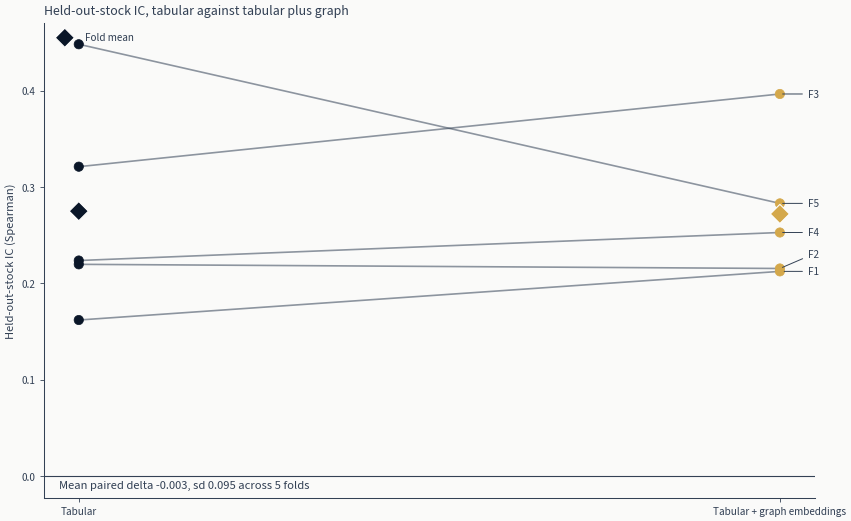

In [21]:
ax.scatter(
    [0, 1],
    [tabular_ic_mean, hybrid_ic_mean],
    marker="D",
    s=95,
    color=[COLORS["blue"], COLORS["amber"]],
    edgecolor="white",
    linewidth=0.8,
    zorder=4,
    label="Fold mean",
)
ax.axhline(0, color=COLORS["neutral"], linewidth=0.8)
ax.set_xticks([0, 1], ["Tabular", "Tabular + graph embeddings"])
ax.set_ylabel("Held-out-stock IC (Spearman)")
ax.set_title("Held-out-stock IC, tabular against tabular plus graph")
ax.text(
    0.02,
    0.02,
    f"Mean paired delta {mean_ic_delta:+.3f}, sd {delta_sd:.3f} across {len(fold_deltas)} folds",
    transform=ax.transAxes,
    color=COLORS["neutral"],
)
ax.legend(frameon=False, loc="upper left")
show_with_alt(
    fig,
    f"A slope chart with two columns, tabular on the left and tabular plus graph "
    f"embeddings on the right, joined by one line per fold. "
    f"{folds_favouring_hybrid} of {len(fold_deltas)} lines end higher on the right "
    f"and {len(fold_deltas) - folds_favouring_hybrid} end lower, the widest single "
    f"gap being {abs(largest_adverse):.3f} of IC on a line that ends lower. The two "
    f"diamonds mark the fold means, which sit close together.",
)

## 6. Inspect the graph input

A distribution view is more legible than a 200-node hairball. The left panel
shows which correlations cross the edge threshold; the right panel shows how
unevenly those edges are distributed across stocks.

The left tail of the degree histogram is where the ablation's ceiling is. A stock
with no edge has no neighbours to aggregate, so its graph embedding carries only
its own features passed through the encoder, and the hybrid model sees nothing
the tabular model does not. The count printed above says how much of the universe
is in that position, and the threshold is what puts it there: raise it and more
stocks become isolated, lower it and the edges stop meaning strong co-movement.

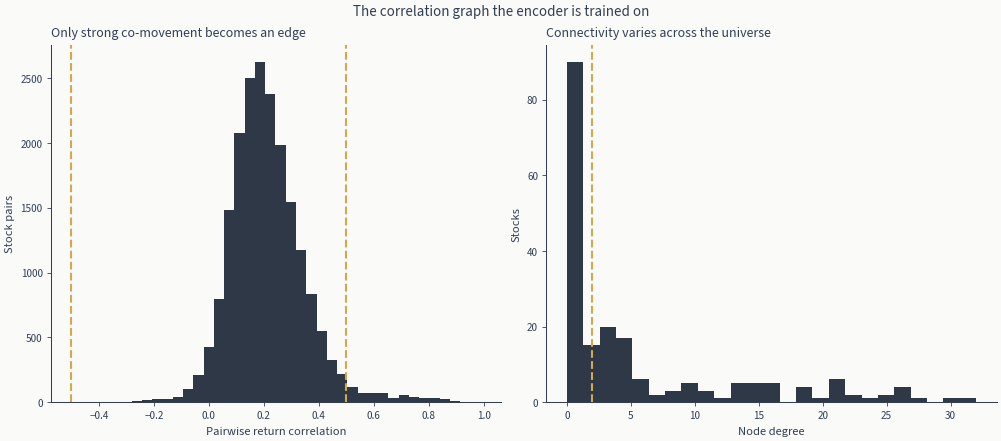

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.4), layout="constrained")
axes[0].hist(corr_values, bins=35, color=COLORS["blue"], alpha=0.85)
axes[0].axvline(CORRELATION_THRESHOLD, color=COLORS["amber"], linestyle="--", linewidth=1.5)
axes[0].axvline(-CORRELATION_THRESHOLD, color=COLORS["amber"], linestyle="--", linewidth=1.5)
axes[0].set_xlabel("Pairwise return correlation")
axes[0].set_ylabel("Stock pairs")
axes[0].set_title("Only strong co-movement becomes an edge")

axes[1].hist(degrees, bins=25, color=COLORS["blue"], alpha=0.85)
axes[1].axvline(np.median(degrees), color=COLORS["amber"], linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Node degree")
axes[1].set_ylabel("Stocks")
axes[1].set_title("Connectivity varies across the universe")
fig.suptitle("The correlation graph the encoder is trained on")
show_with_alt(
    fig,
    f"Two histograms. The left one bins the {len(corr_values):,} pairwise return "
    f"correlations, with dashed lines at plus and minus the "
    f"{CORRELATION_THRESHOLD:.2f} edge threshold marking the tails that become "
    f"edges. The right one bins node degree across {len(degrees)} stocks, with a "
    f"dashed line at the median of {np.median(degrees):.0f}.",
)

## 7. Verification and chapter-impact summary

In [23]:
assert universe["last_observation"].max() == feature_as_of
assert set(selected_symbols).issubset(set(endpoint_complete_symbols["symbol"].to_list()))
assert returns_wide["timestamp"].max() == feature_as_of
assert np.isfinite(node_features).all()
assert np.isfinite(target).all()
assert fold_results["held_out_stocks"].sum() == len(symbol_order)
assert fold_results["fold"].n_unique() == 5

results = pl.DataFrame(
    {
        "metric": [
            "feature as-of",
            "target end",
            "assets",
            "graph edges",
            "graph density",
            "graph encoder device",
            "mean tabular IC",
            "mean hybrid IC",
            "mean paired IC delta",
        ],
        "value": [
            str(feature_as_of),
            str(evaluation_end),
            str(len(symbol_order)),
            str(n_edges),
            f"{graph_density:.2%}",
            str(DEVICE),
            f"{tabular_ic_mean:+.4f}",
            f"{hybrid_ic_mean:+.4f}",
            f"{mean_ic_delta:+.4f}",
        ],
    }
)
results

metric,value
str,str
"""feature as-of""","""2018-02-26"""
"""target end""","""2018-03-27"""
"""assets""","""200"""
"""graph edges""","""559"""
"""graph density""","""2.81%"""
"""graph encoder device""","""cuda"""
"""mean tabular IC""","""+0.2749"""
"""mean hybrid IC""","""+0.2720"""
"""mean paired IC delta""","""-0.0029"""


The frozen chapter reports results from an earlier implementation that selected
the universe with full-sample liquidity, standardized before cross-validation,
and passed randomly initialized projections off as GNN embeddings. Those
numbers are not comparable to this corrected experiment and must be treated as
a documented book-code divergence.

## Key takeaways

1. **Train the representation**: Random graph projections are not learned GNN embeddings.
2. **Fit preprocessing inside the fold**: Even cross-sectional scaling can leak held-out data.
3. **Use a pre-target universe**: Future liquidity cannot decide today's investable set.
4. **Report the spread, not the mean**: the folds disagree in sign here and the
   mean sits a fraction of a standard error from zero, so the experiment does not
   resolve which way the effect goes on its own sample.
5. **Interpret the ablation narrowly**: five stock folds from one target window
   do not settle whether GNNs help across markets or time.